<a href="https://colab.research.google.com/github/yimgakevin/machine-learning/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Realiser une ACP
Nous allons importer nos librairies :

In [1]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

import seaborn as sns

Charger le jeu de donnée

In [2]:
df = pd.read_csv("/content/my_courses.csv", decimal=".", index_col=0)
df.head()

,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations,derniereMiseAJour,idCours
titreCours,,,,,,,,,,
Classez_et_segmentez_des_données_visuelles,29,34,NaN,15.0,3,11,0.666667,3,22,4470531
Initiez-vous_à_la_statistique_inférentielle,55,4,86.0,12.0,2,21,0.750000,4,8,4525306
Maîtrisez_les_bases_des_probabilités,60,100,NaN,NaN,1,1,NaN,0,89,4525296
Découvrez_les_librairies_Python_pour_la_Data_Science,64,64,96.0,10.0,2,8,0.000000,2,57,4452741
Devenez_mentor_sur_OpenClassrooms,76,100,91.0,6.0,1,12,1.000000,3,29,3595541


In [3]:
df.shape

(19, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, Classez_et_segmentez_des_données_visuelles to Développez_votre_site_web_avec_le_framework_Symfony
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   inscription          19 non-null     int64  
 1   progression          19 non-null     int64  
 2   moyenneDeClasse      15 non-null     float64
 3   duree                18 non-null     float64
 4   difficulte           19 non-null     int64  
 5   nbChapitres          19 non-null     int64  
 6   ratioQuizEvaluation  16 non-null     float64
 7   nbEvaluations        19 non-null     int64  
 8   derniereMiseAJour    19 non-null     int64  
 9   idCours              19 non-null     int64  
dtypes: float64(3), int64(7)
memory usage: 1.6+ KB


In [5]:
# Quel est le % de valeurs manquantes par colonne ?
df.isna().mean()

,0
inscription,0.000000
progression,0.000000
moyenneDeClasse,0.210526
duree,0.052632
difficulte,0.000000
nbChapitres,0.000000
ratioQuizEvaluation,0.157895
nbEvaluations,0.000000
derniereMiseAJour,0.000000
idCours,0.000000


In [6]:
# Y a-t-il des lignes en double ?
df.duplicated().sum()

np.int64(0)

In [7]:
# Combien y a-t-il de valeurs différentes par colonne ?
df.nunique()

,0
inscription,17
progression,13
moyenneDeClasse,11
duree,10
difficulte,3
nbChapitres,18
ratioQuizEvaluation,7
nbEvaluations,5
derniereMiseAJour,17
idCours,19


In [8]:
df.describe()

,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations,derniereMiseAJour,idCours
count,19.000000,19.000000,15.000000,18.000000,19.000000,19.000000,16.000000,19.000000,19.000000,1.900000e+01
mean,235.473684,44.052632,89.400000,15.000000,1.894737,15.210526,0.617560,2.947368,78.578947,3.967983e+06
std,167.684349,36.326412,3.996427,10.318459,0.657836,9.223032,0.246053,1.715086,63.453671,1.075638e+06
min,29.000000,2.000000,84.000000,1.000000,1.000000,1.000000,0.000000,0.000000,8.000000,2.353440e+05
25%,134.000000,4.000000,85.500000,8.500000,1.500000,8.500000,0.500000,2.000000,22.000000,4.056556e+06
50%,195.000000,44.000000,90.000000,13.500000,2.000000,13.000000,0.666667,3.000000,61.000000,4.421146e+06
75%,310.500000,70.000000,92.000000,20.000000,2.000000,20.500000,0.750000,4.000000,146.500000,4.469006e+06
max,713.000000,100.000000,96.000000,40.000000,3.000000,38.000000,1.000000,7.000000,186.000000,4.525306e+06


In [9]:
# Nous allons sélectionner d'abord que certaines colones :
cols = ["inscription","progression","moyenneDeClasse","duree","difficulte","nbChapitres","ratioQuizEvaluation","nbEvaluations"]

In [10]:
df = df[cols]
df.head()

,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations
titreCours,,,,,,,,
Classez_et_segmentez_des_données_visuelles,29,34,NaN,15.0,3,11,0.666667,3
Initiez-vous_à_la_statistique_inférentielle,55,4,86.0,12.0,2,21,0.750000,4
Maîtrisez_les_bases_des_probabilités,60,100,NaN,NaN,1,1,NaN,0
Découvrez_les_librairies_Python_pour_la_Data_Science,64,64,96.0,10.0,2,8,0.000000,2
Devenez_mentor_sur_OpenClassrooms,76,100,91.0,6.0,1,12,1.000000,3


In [11]:
df.shape

(19, 8)

In [12]:
# Traitons les valeurs manquantes. On rappelle que :
df.isna().sum()

,0
inscription,0
progression,0
moyenneDeClasse,4
duree,1
difficulte,0
nbChapitres,0
ratioQuizEvaluation,3
nbEvaluations,0


In [13]:
# Dans notre cas, nous pouvons simplement imputer les valeurs manquantes par la moyenne. Cela n'est pas la meilleure chose à faire, mais c'est la plus rapide!
df = df.fillna(df.mean())
df.isna().mean()

,0
inscription,0.0
progression,0.0
moyenneDeClasse,0.0
duree,0.0
difficulte,0.0
nbChapitres,0.0
ratioQuizEvaluation,0.0
nbEvaluations,0.0


## Data split
Nous allons ensuite séparer nos données. D'un coté X la matrice des données :

In [14]:
X = df.values
X[:5]

array([[ 29.        ,  34.        ,  89.4       ,  15.        ,
          3.        ,  11.        ,   0.66666667,   3.        ],
       [ 55.        ,   4.        ,  86.        ,  12.        ,
          2.        ,  21.        ,   0.75      ,   4.        ],
       [ 60.        , 100.        ,  89.4       ,  15.        ,
          1.        ,   1.        ,   0.61755952,   0.        ],
       [ 64.        ,  64.        ,  96.        ,  10.        ,
          2.        ,   8.        ,   0.        ,   2.        ],
       [ 76.        , 100.        ,  91.        ,   6.        ,
          1.        ,  12.        ,   1.        ,   3.        ]])

In [15]:
type(X)

numpy.ndarray

In [16]:
X.shape

(19, 8)

In [17]:
# Nous enregistrons les noms de nos cours dans une variable names :
names = df.index
names

Index(['Classez_et_segmentez_des_données_visuelles',
       'Initiez-vous_à_la_statistique_inférentielle',
       'Maîtrisez_les_bases_des_probabilités',
       'Découvrez_les_librairies_Python_pour_la_Data_Science',
       'Devenez_mentor_sur_OpenClassrooms',
       'Initiez-vous_à_l'algèbre_relationnelle_avec_le_langage_SQL',
       'Maintenez-vous_à_jour_en_développement',
       'Entraînez_un_modèle_prédictif_linéaire',
       'Explorez_vos_données_avec_des_algorithmes_non_supervisés',
       'Décrivez_et_nettoyez_votre_jeu_de_données', 'Créez_votre_Data_Lake',
       'Développez_une_application_iPhone_avec_le_modèle_MVC',
       'Animez_un_atelier_de_créativité',
       'Faites_une_base_de_données_avec_UML',
       'Apprenez_à_programmer_en_Python',
       'Réalisez_des_calculs_distribués_sur_des_données_massives',
       'Évaluez_et_améliorez_les_performances_d'un_modèle_de_machine_learning',
       'Créez_un_cours_sur_OpenClassrooms',
       'Développez_votre_site_web_avec_le_fr

In [18]:
# et nos colonnes, nos features, dans une variable features :
features = df.columns
features

Index(['inscription', 'progression', 'moyenneDeClasse', 'duree', 'difficulte',
       'nbChapitres', 'ratioQuizEvaluation', 'nbEvaluations'],
      dtype='object')

## About PCA
Nous pouvons - enfin - commencer notre ACP, ou notre PCA !

### Scaling
Commençons par scaler les données. On instancie :

In [19]:
scaler = StandardScaler()

In [20]:
# on fit
scaler.fit(X)

StandardScaler()

In [21]:
# on transforme
X_scaled = scaler.transform(X)
X_scaled[:5]

array([[-1.26506467e+00, -2.84313717e-01,  4.14248649e-15,
         0.00000000e+00,  1.72618937e+00, -4.69032782e-01,
         2.24619768e-01,  3.15283331e-02],
       [-1.10576261e+00, -1.13278921e+00, -9.91105344e-01,
        -3.07368082e-01,  1.64398987e-01,  6.44920075e-01,
         6.05792707e-01,  6.30566661e-01],
       [-1.07512761e+00,  1.58233236e+00,  4.14248649e-15,
         0.00000000e+00, -1.39739139e+00, -1.58298564e+00,
         0.00000000e+00, -1.76558665e+00],
       [-1.05061960e+00,  5.64161774e-01,  1.92391037e+00,
        -5.12280137e-01,  1.64398987e-01, -8.03218639e-01,
        -2.82476374e+00, -5.67509995e-01],
       [-9.77095574e-01,  1.58233236e+00,  4.66402515e-01,
        -9.22104247e-01, -1.39739139e+00, -3.57637496e-01,
         1.74931152e+00,  3.15283331e-02]])

In [23]:
idx = ["mean", "std"]
pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]


,0,1,2,3,4,5,6,7
mean,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00
std,1.03,1.03,1.03,1.03,1.03,1.03,1.03,1.03


In [24]:
# Nous allons travailler que sur les 6 premières composantes :
n_components = 6
# on instancie notre ACP:
pca = PCA(n_components=n_components)

In [25]:
# On l'entraine sur les données scalées :
pca.fit(X_scaled)

PCA(n_components=6)

###  Explained variance & scree plot
Intéressons nous maintenant à la variance captée par chaque nouvelle composante. Grace à scikit-learn on peut utiliser l'attribut explained_variance_ratio_ :

In [27]:
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([47.16, 15.65, 13.68, 11.91,  4.15,  3.04])

nous voyons ici qu'ci la 1ère composante capte 47% de la variance de nos données initiales, la 2ème 15,65% etc.

Les 2 premières composantes captent donc 47+16 = 63% de la variance, les 3 premières 47,16+15,65+13,68 = 76% de la variance etc etc.

Dans le jargon, cela s'appelle une somme cumulée. Et pour faire une somme cumulée numpy dispose de la fonction cumsum :

In [28]:
scree_cum = scree.cumsum().round()
scree_cum

array([47., 63., 76., 88., 93., 96.])

In [29]:
# Définisons ensuite une variable avec la liste de nos composantes :
x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3, 4, 5, 6]

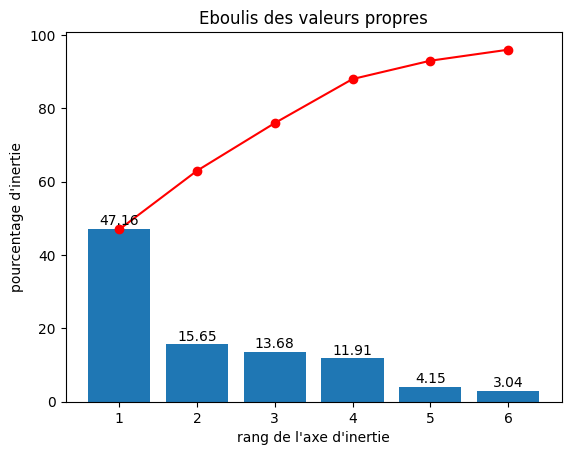

In [31]:
# On peut enfin l'afficher de façon graphique :
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")

# Add values on top of each bar
for i, v in enumerate(scree):
    plt.text(x_list[i], v + 1, str(v), color='black', ha='center')

plt.show(block=False)

On a en bleu la variance de chaque nouvelle composante, et en rouge la variance cumulée.

On voit ici que près de 80% de la variance est comprise dans les 3 premières composantes, et près de 90% dans les 4 premières.

### Components
Intéressons nous maintenant à nos fameuses composantes. Nous avons dit dans le cours que c'est bien par un calcul que l'on obtient ces composantes.

La formule de ce calcul nous est donnée par l'attribut components_. Cette variable est généralement nommée pcs :

In [32]:
pcs = pca.components_
pcs

array([[ 0.23229081, -0.45303568, -0.08449592,  0.44865413,  0.33114918,
         0.4643896 ,  0.08103545,  0.4477559 ],
       [-0.1385512 ,  0.09570881, -0.50590131,  0.11946397,  0.56702258,
        -0.14819996, -0.55994188, -0.21076734],
       [-0.2329107 , -0.18131195,  0.74959103,  0.02578145,  0.09797129,
         0.00162489, -0.57772613,  0.08341881],
       [ 0.84456256,  0.17345083, -0.00374152, -0.00379675, -0.2511345 ,
        -0.03195603, -0.43707483,  0.0384231 ],
       [-0.1019438 ,  0.10374663,  0.04280049,  0.7043421 , -0.33049795,
         0.25476797, -0.03959608, -0.552459  ],
       [-0.24178329, -0.28083669, -0.34571373, -0.38205031, -0.44706348,
         0.52232025, -0.35266466,  0.01160229]])

In [33]:
# affichons la meme chose avec pandas
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7
0,0.232291,-0.453036,-0.084496,0.448654,0.331149,0.464390,0.081035,0.447756
1,-0.138551,0.095709,-0.505901,0.119464,0.567023,-0.148200,-0.559942,-0.210767
2,-0.232911,-0.181312,0.749591,0.025781,0.097971,0.001625,-0.577726,0.083419
3,0.844563,0.173451,-0.003742,-0.003797,-0.251135,-0.031956,-0.437075,0.038423
4,-0.101944,0.103747,0.042800,0.704342,-0.330498,0.254768,-0.039596,-0.552459
5,-0.241783,-0.280837,-0.345714,-0.382050,-0.447063,0.522320,-0.352665,0.011602


In [36]:
pcs.columns = features
pcs.index = [f"F{i}" for i in x_list]
pcs


,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations
F1,0.232291,-0.453036,-0.084496,0.448654,0.331149,0.464390,0.081035,0.447756
F2,-0.138551,0.095709,-0.505901,0.119464,0.567023,-0.148200,-0.559942,-0.210767
F3,-0.232911,-0.181312,0.749591,0.025781,0.097971,0.001625,-0.577726,0.083419
F4,0.844563,0.173451,-0.003742,-0.003797,-0.251135,-0.031956,-0.437075,0.038423
F5,-0.101944,0.103747,0.042800,0.704342,-0.330498,0.254768,-0.039596,-0.552459
F6,-0.241783,-0.280837,-0.345714,-0.382050,-0.447063,0.522320,-0.352665,0.011602


Alors, comment calcule t-on la première composante F1 ?

et bien c'est assez simple :

F1 = (0.23 * inscription) + (-0.45 * progression) + ... + (0.45 * nbEvaluations)

et F2 ?

F2 = (0.14 * inscription) + (-0.10 * progression) + ... + (0.21 * nbEvaluations)

<Axes: >

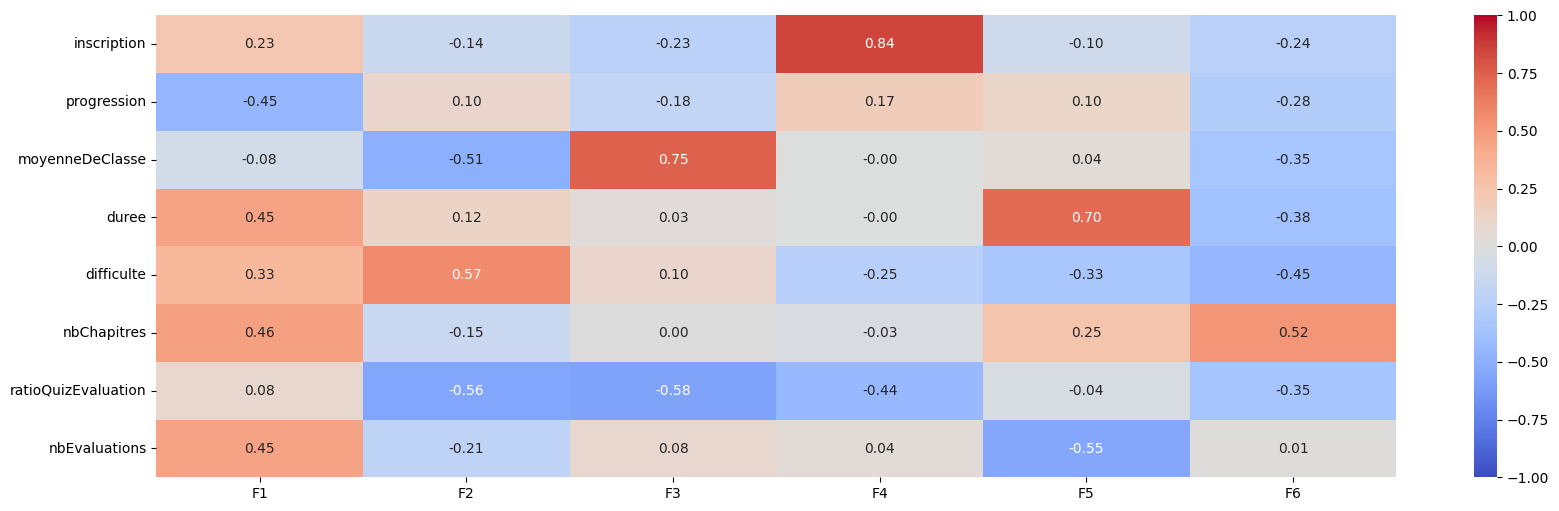

In [37]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

Définissons nos axes x et y. Nous allons utiliser les 2 premières composantes. Comme - en code - on commence à compter à partir de 0, cela nous donne :

In [38]:
x, y = 0,1

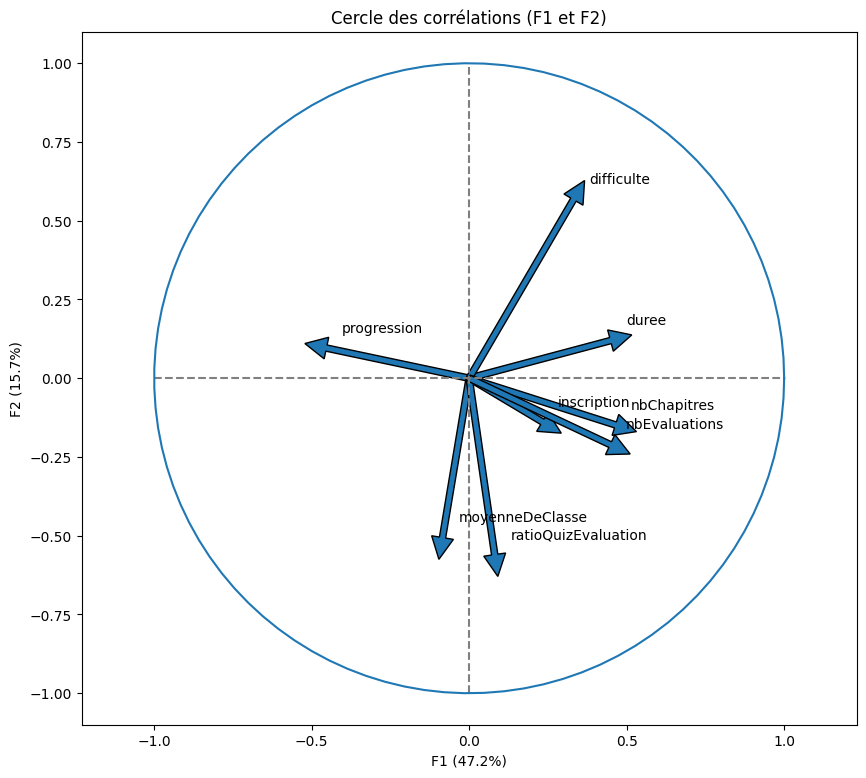

In [39]:
fig, ax = plt.subplots(figsize=(10, 9))
for i in range(0, pca.components_.shape[1]):
    ax.arrow(0,
             0,  # Start the arrow at the origin
             pca.components_[0, i],  #0 for PC1
             pca.components_[1, i],  #1 for PC2
             head_width=0.07,
             head_length=0.07,
             width=0.02,              )

    plt.text(pca.components_[0, i] + 0.05,
             pca.components_[1, i] + 0.05,
             features[i])

# affichage des lignes horizontales et verticales
plt.plot([-1, 1], [0, 0], color='grey', ls='--')
plt.plot([0, 0], [-1, 1], color='grey', ls='--')


# nom des axes, avec le pourcentage d'inertie expliqué
plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))


an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale
plt.axis('equal')
plt.show(block=False)

In [40]:
def correlation_graph(pca,
                      x_y,
                      features) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

In [41]:
x_y = (0,1)
x_y

(0, 1)

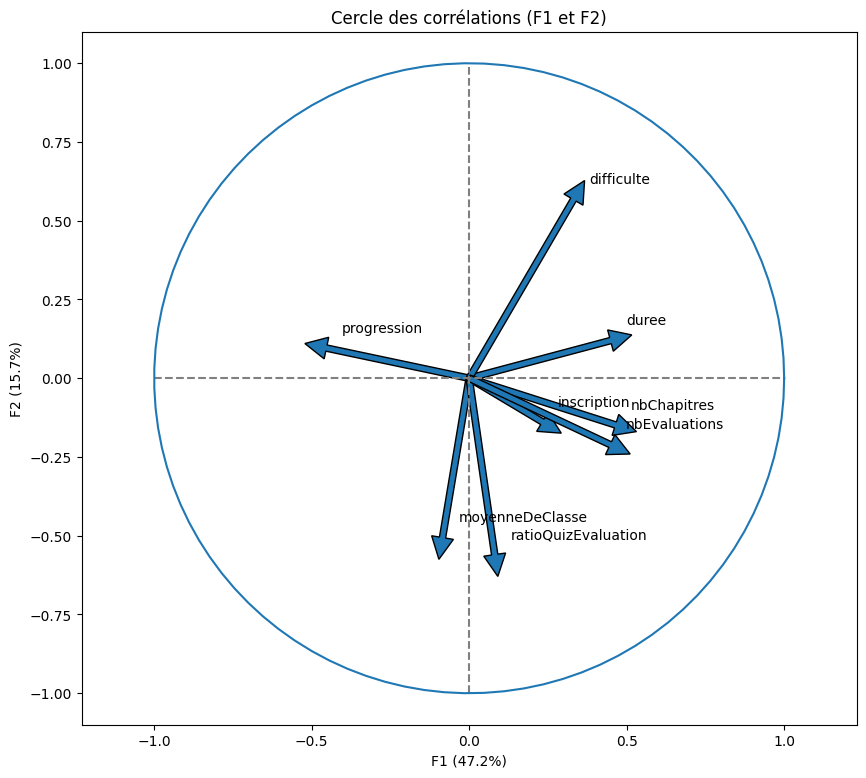

In [42]:
correlation_graph(pca, x_y, features)

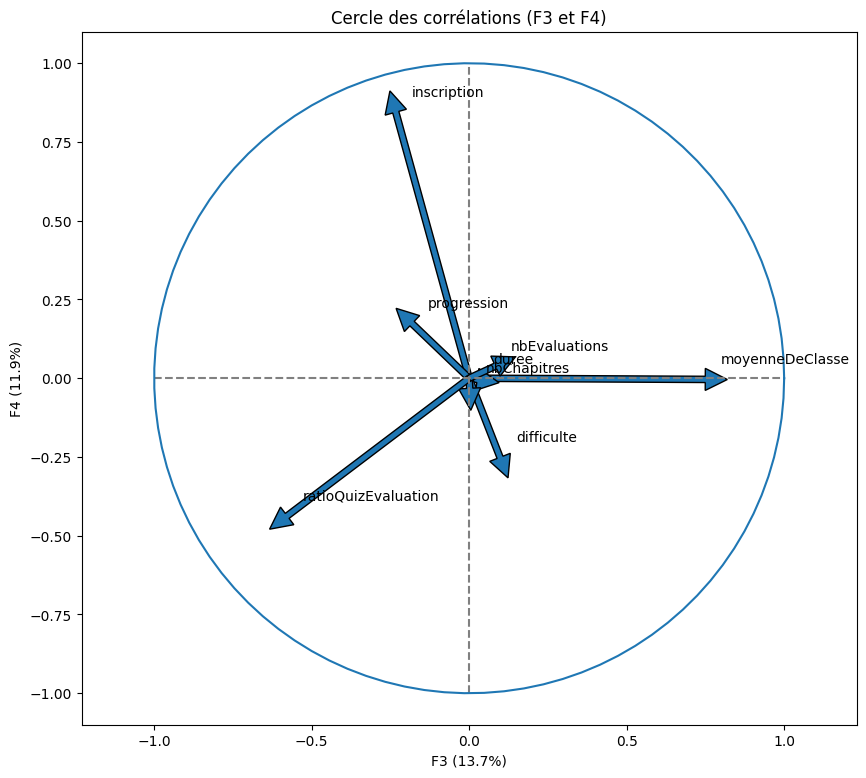

In [43]:
correlation_graph(pca, (2,3), features)

### Projection
Travaillons maintenant sur la projection de nos dimensions. Tout d'abord calculons les coordonnées de nos individus dans le nouvel espace :

In [44]:
X_proj = pca.transform(X_scaled)
X_proj[:5]

array([[ 0.22107277,  1.06394473,  0.3874128 , -1.63322222, -0.61683984,
        -0.70983399],
       [ 0.88754323,  0.03499815, -0.56814276, -1.42793746, -0.52608729,
         1.10258485],
       [-2.95501419,  0.11477732, -0.3232466 , -0.29987584,  1.30771945,
        -0.40701673],
       [-1.69361161,  1.07862307,  3.17074995,  0.40249607,  0.05356553,
         0.12275527],
       [-1.86989322, -1.7847995 , -0.87896007, -0.9500123 , -0.08170767,
        -0.19571633]])

In [45]:
x_y

(0, 1)

In [46]:
def display_factorial_planes(   X_projected,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[10,8],
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments :
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments :
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8]
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        # j'ai copié collé la fonction sans la lire
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()

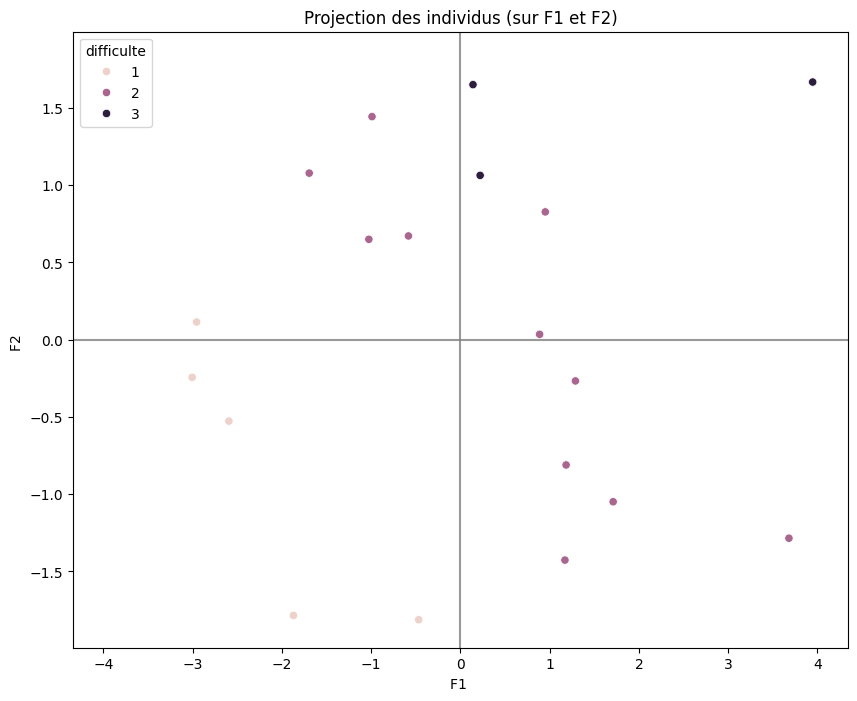

In [47]:
x_y = [0,1]
display_factorial_planes(X_proj, x_y, clusters=df['difficulte'])

Essayons la version plus élaborée avec F1 et F2 :

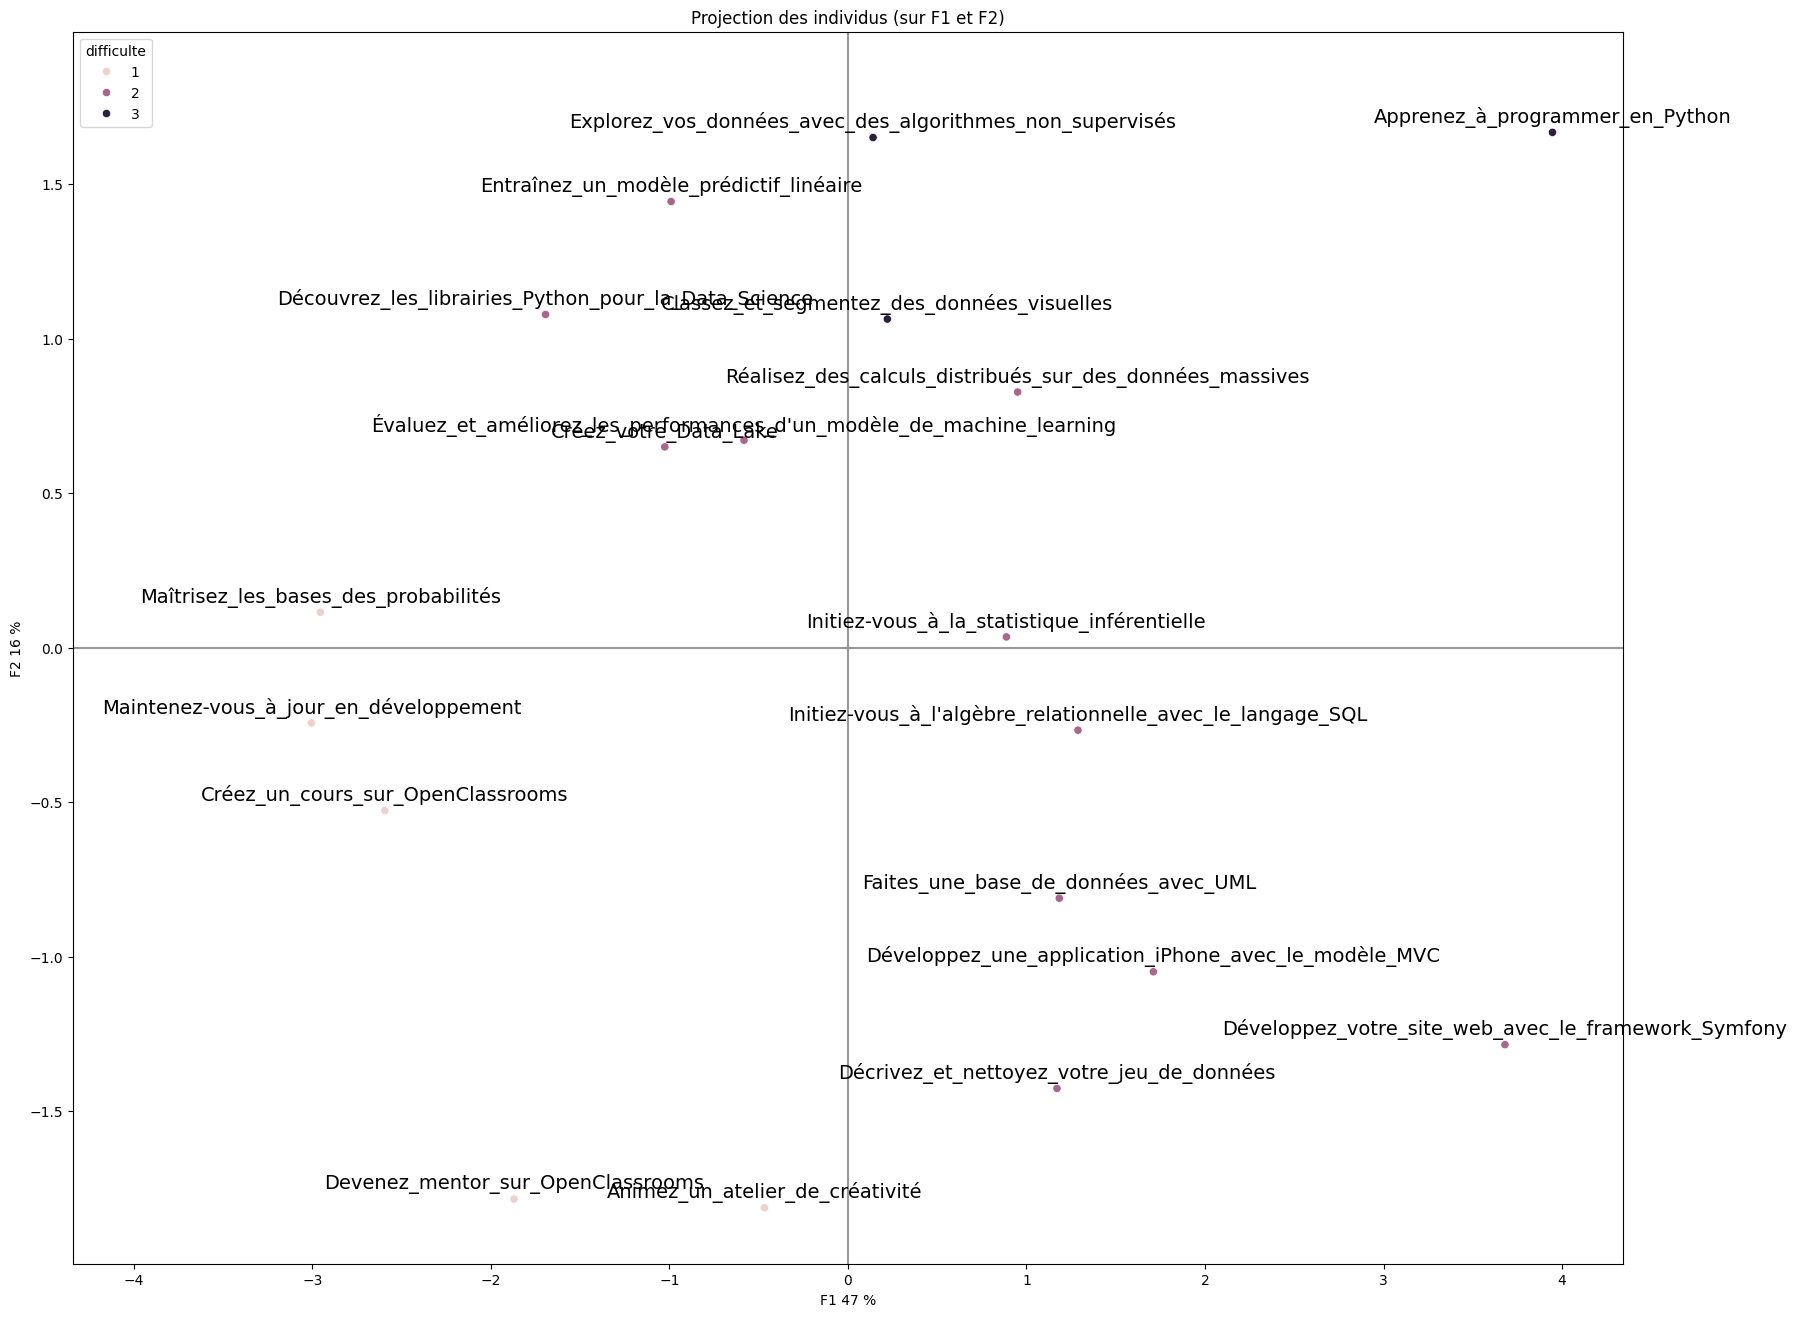

In [51]:
x_y = [0,1]
display_factorial_planes(X_proj, x_y, pca, labels=names, figsize=(20,16), clusters=df['difficulte'], marker="o")

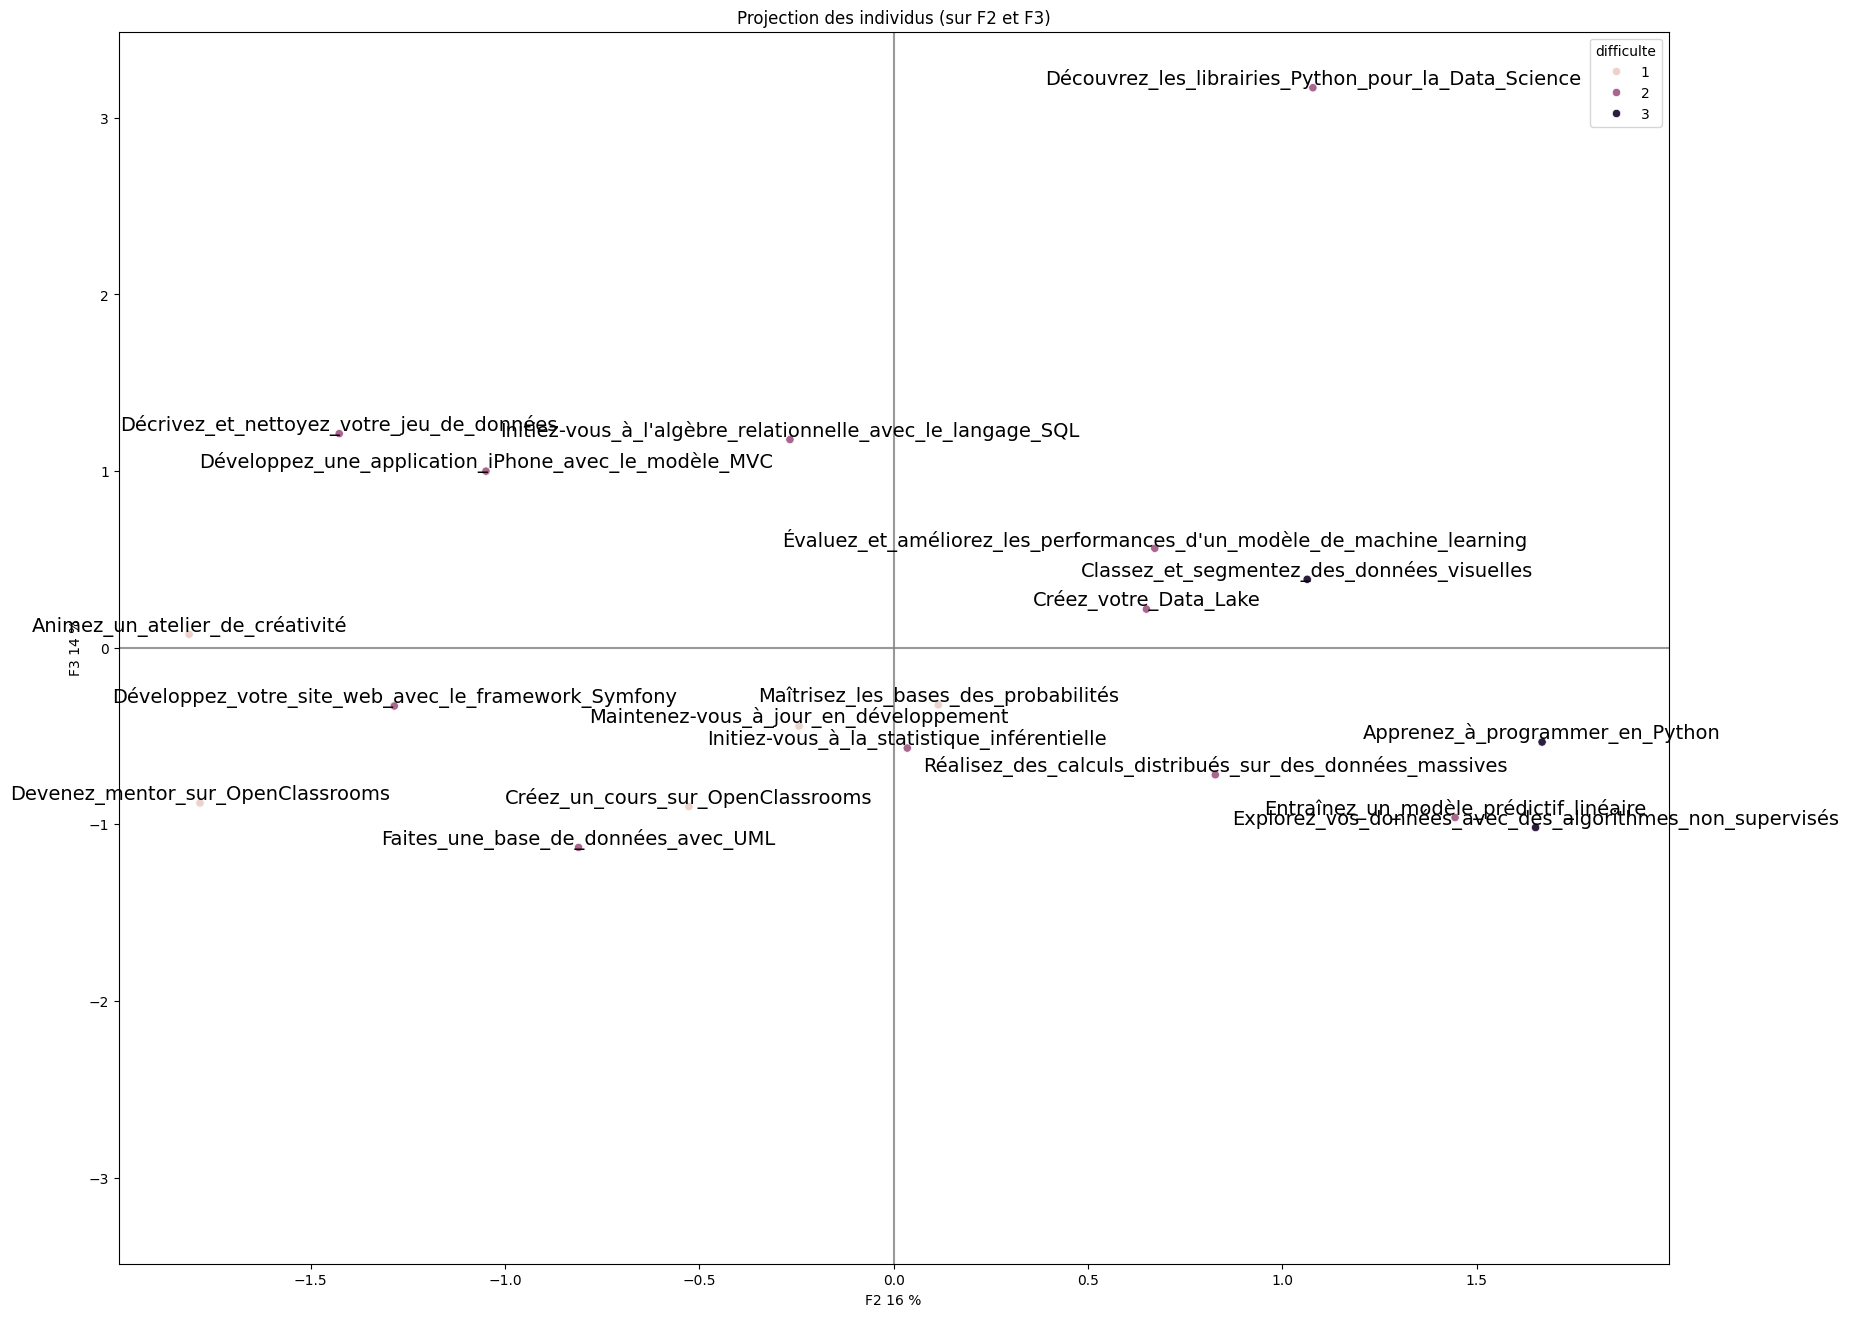

In [52]:
# essayons F2 et F3
x_y = 1,2
display_factorial_planes(X_proj, x_y, pca, labels=names, figsize=(20,16), clusters=df['difficulte'],marker="o")

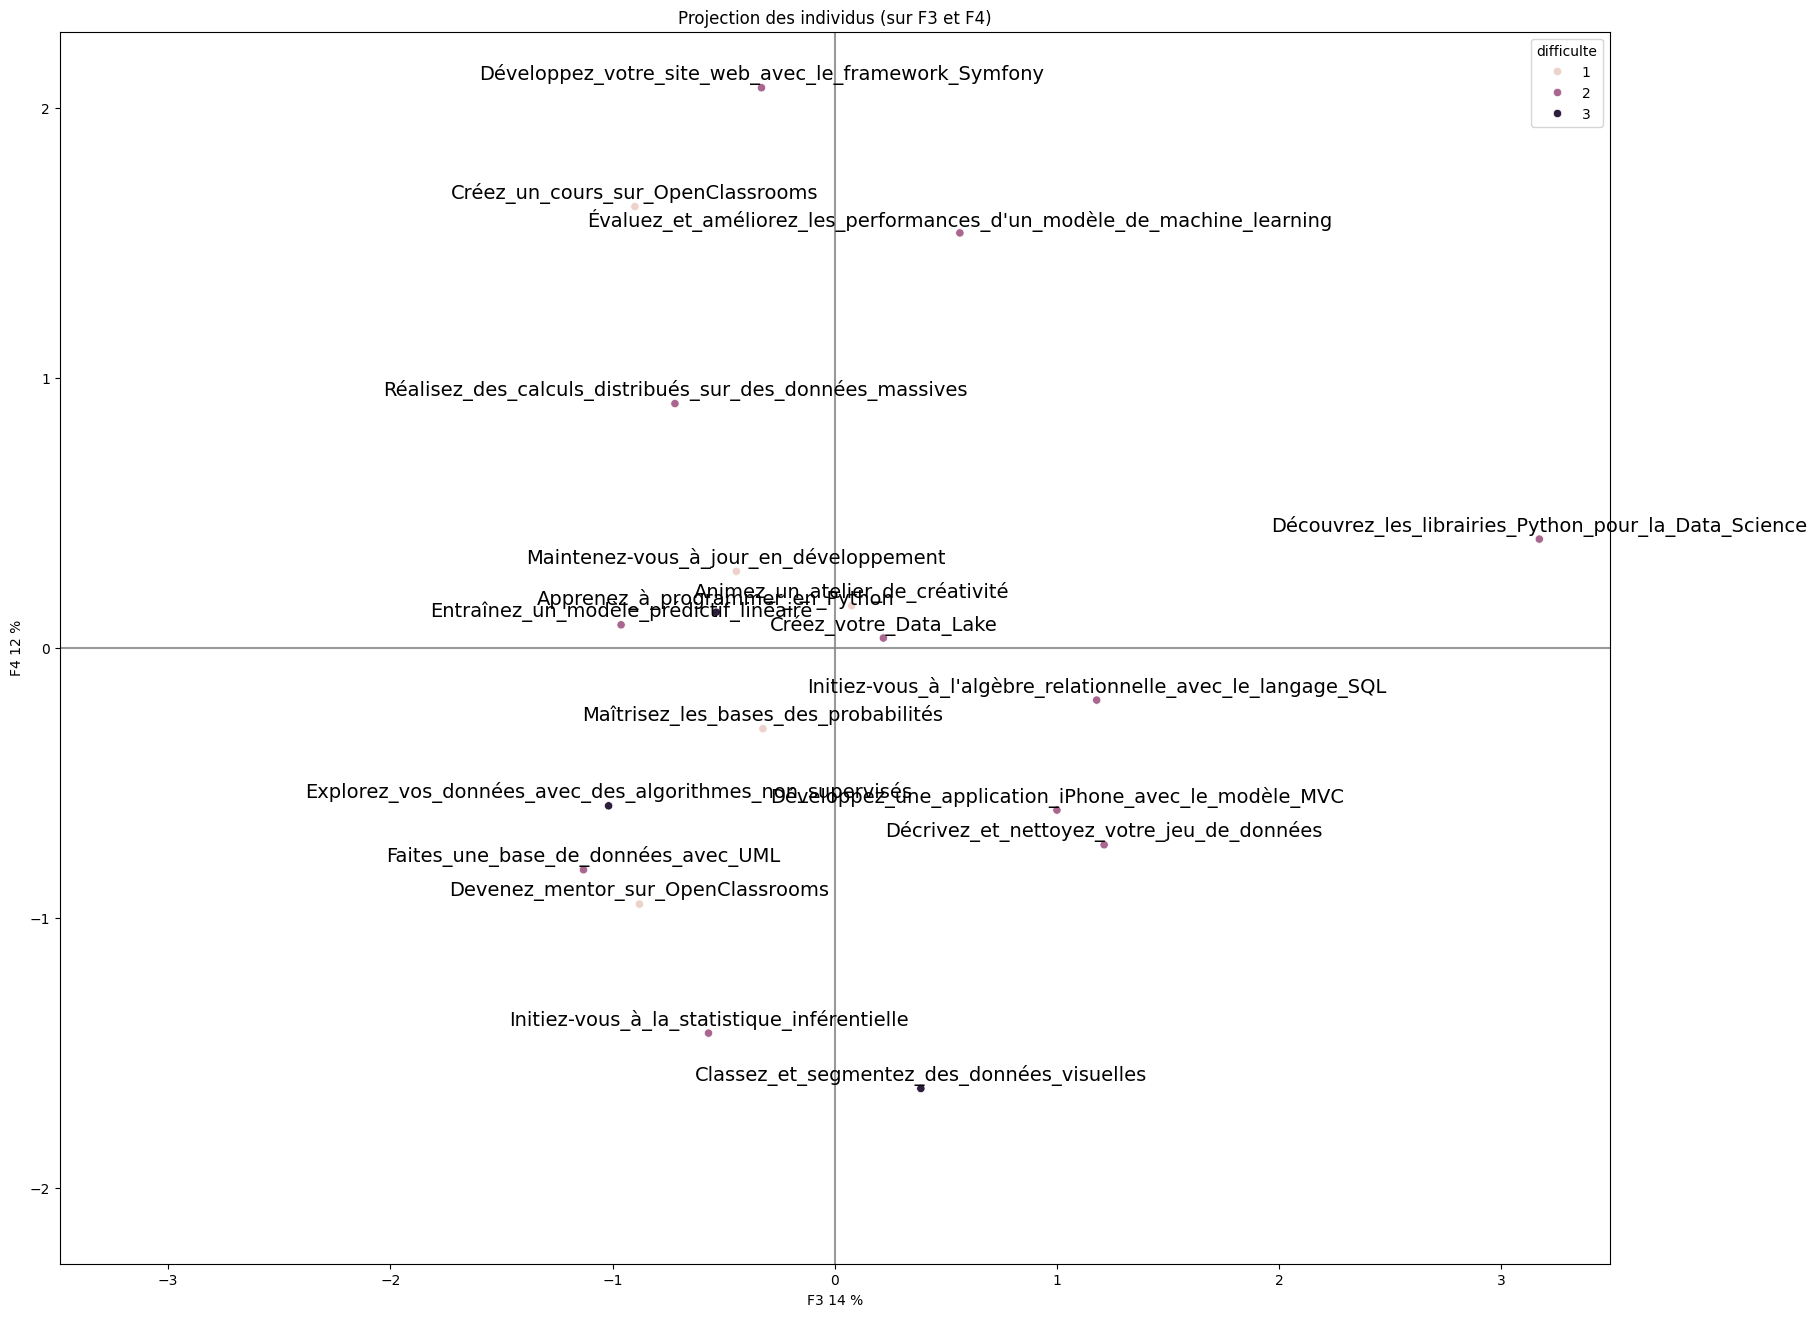

In [53]:
# Essayons F3 et F4
x_y = 2,3
display_factorial_planes(X_proj, x_y, pca, labels=names, figsize=(20,16), clusters=df['difficulte'],marker="o")

In [1]:
# importer les packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from  sklearn.cluster import KMeans

In [13]:
# charger le jeu de donnée
iris = datasets.load_iris()

In [14]:
# on le transforme en data frame pandas
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.columns = [i.split('(')[0].replace(" ", "_")[:-1] for i in df.columns]
X = df.copy()

In [15]:
# visualiser ma base de donnée
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
# Une liste vide pour enregistrer les inerties :
intertia_list = [ ]

# Notre liste de nombres de clusters :
k_list = range(1, 10)
# Pour chaque nombre de clusters :
for k in k_list :

    # On instancie un k-means pour k clusters
    kmeans = KMeans(n_clusters=k)

    # On entraine
    kmeans.fit(X)

    # On enregistre l'inertie obtenue :
    intertia_list.append(kmeans.inertia_)

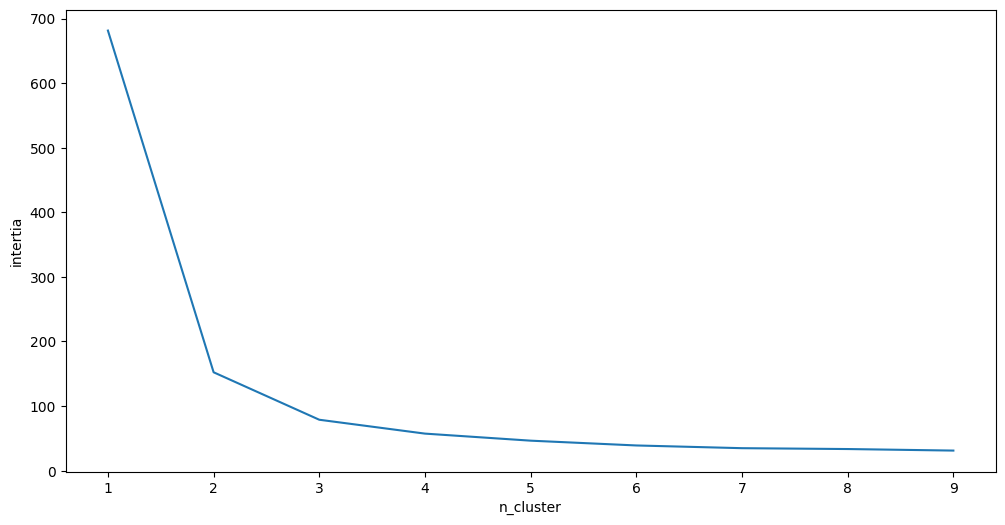

In [12]:
fig, ax = plt.subplots(1,1,figsize=(12,6))

ax.set_ylabel("intertia")
ax.set_xlabel("n_cluster")

ax = plt.plot(k_list, intertia_list)

In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [17]:
Z = linkage(X, method="ward")

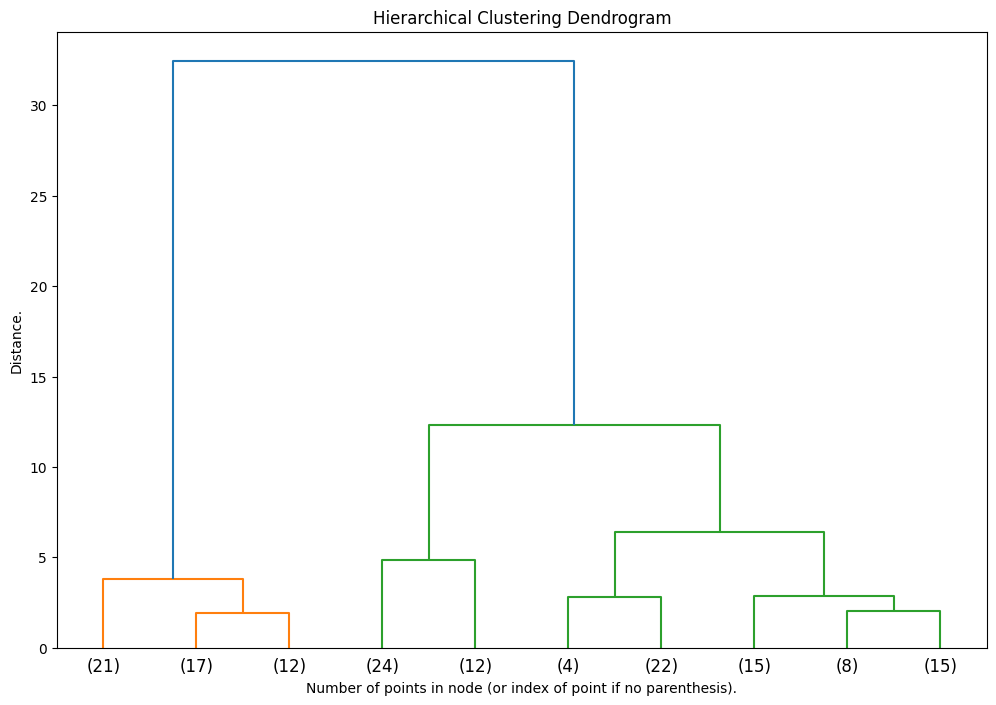

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

_ = dendrogram(Z, p=10, truncate_mode="lastp", ax=ax)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Distance.")
plt.show()

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [23]:
# on instancie notre kmeans avec 3 clusters
kmeans = KMeans(n_clusters=3)
# On entraine notre kmeans
kmeans.fit(X)
# On peut stocker nos clusters dans une variable labels :
labels = kmeans.labels_
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

In [24]:
centroids = kmeans.cluster_centers_
centroids

array([[6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [5.88360656, 2.74098361, 4.38852459, 1.43442623]])

In [25]:
# scaler le modéle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
# ensuite on fait notre ACP ainsi avec 3 composantes
pca = PCA(n_components=3)
pca.fit(X_scaled)

PCA(n_components=3)

In [27]:
# on projette nos points dans le nouvel espaces
X_proj = pca.transform(X_scaled)
X_proj = pd.DataFrame(X_proj, columns=["PC1", "PC2", "PC3"])
X_proj[:10]

,PC1,PC2,PC3
0,-2.264703,0.480027,0.127706
1,-2.080961,-0.674134,0.234609
2,-2.364229,-0.341908,-0.044201
3,-2.299384,-0.597395,-0.091290
4,-2.389842,0.646835,-0.015738
5,-2.075631,1.489178,-0.026968
6,-2.444029,0.047644,-0.335470
7,-2.232847,0.223148,0.088695
8,-2.334640,-1.115328,-0.145077
9,-2.184328,-0.469014,0.253766


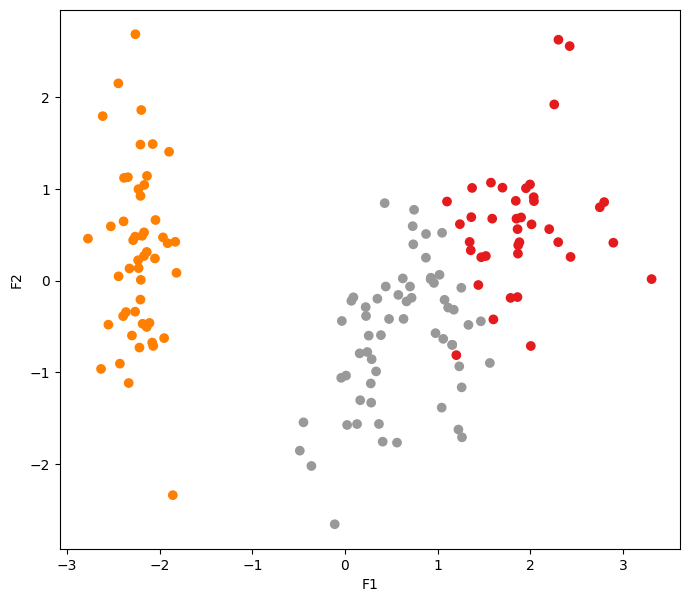

In [28]:
# Visualiser
fig, ax = plt.subplots(1,1, figsize=(8,7))
ax.scatter(X_proj.iloc[:, 0], X_proj.iloc[:, 1], c= labels, cmap="Set1")
ax.set_xlabel("F1")
ax.set_ylabel("F2")
plt.show()

In [29]:
# On utilise bien le scaler déjà entrainé :
centroids_scaled = scaler.fit_transform(centroids)

In [30]:
# et on utilise l'ACP déjà entrainée :
centroids_proj = pca.transform(centroids_scaled)


In [32]:
# Création d'un dataframe pour plus de clarté:
centroids_proj = pd.DataFrame(centroids_proj,
                              columns = ["F1", "F2", "F3"],
                              index=["cluster_0", "cluster_1", "cluster_2"])

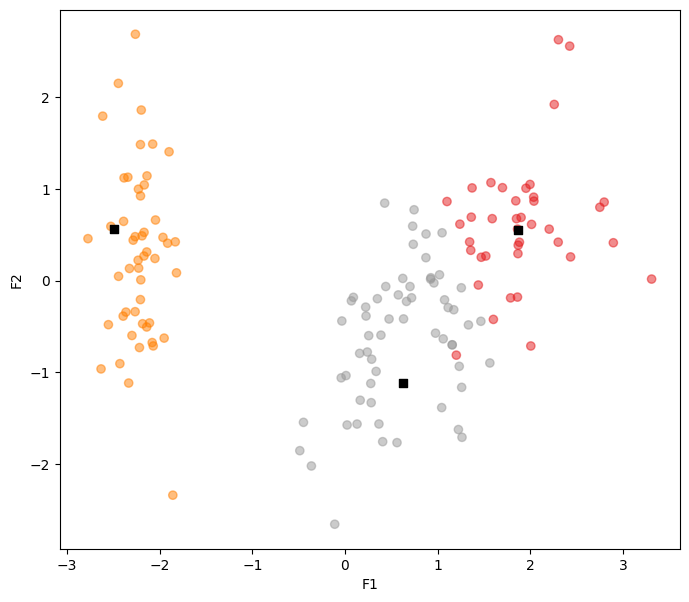

In [33]:
# On définit notre figure et son axe :
fig, ax = plt.subplots(1,1, figsize=(8,7))

# On affiche nos individus, avec une transparence de 50% (alpha=0.5) :
ax.scatter(X_proj.iloc[:, 0], X_proj.iloc[:, 1], c= labels, cmap="Set1", alpha =0.5)

# On affiche nos centroides, avec une couleur noire (c="black") et une frome de carré (marker="c") :
ax.scatter(centroids_proj.iloc[:, 0], centroids_proj.iloc[:, 1],  marker="s", c="black" )

# On spécifie les axes x et y :
ax.set_xlabel("F1")
ax.set_ylabel("F2")
plt.show()

Text(0.5, 0, 'F3')

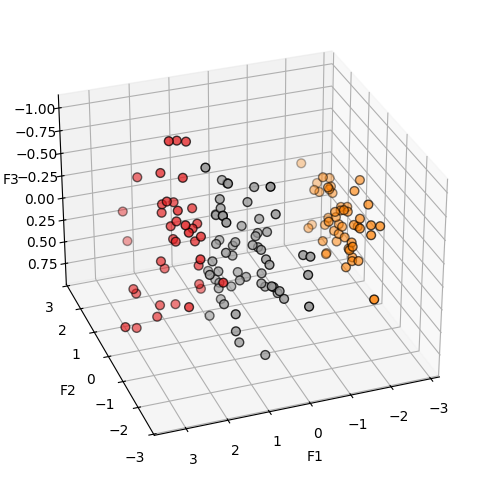

In [34]:
# On définit notre figure et notre axe différemment :
fig= plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

# On affiche nos points :
ax.scatter(
    X_proj.iloc[:, 0],
    X_proj.iloc[:, 1],
    X_proj.iloc[:, 2],
    c=labels, cmap="Set1", edgecolor="k", s=40)

# On spécifie le nom des axes :
ax.set_xlabel("F1")
ax.set_ylabel("F2")
ax.set_zlabel("F3")

# TSNE + projection
  
Comme l'ACP, on instancie le TSNE.

Le TSNE est une méthode plus complexe que l'ACP. Elle prend notamment en paramètres le learning_rate, la perplexity le n_iter.

C'est une méthode non déterminste.

Vous trouverez plus d'information sur cette page. Le 1er lien devrait etre le bon :

In [ ]:
tsne = TSNE(n_components=2, learning_rate=30, init='random', perplexity=30, n_iter=300)
tsne